# CREATE SUPPLEMENTARY FIGURE 5B-D PANELS
## last updated: 06.12.26

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import ast
import itertools
from itertools import combinations
from scipy.stats import mannwhitneyu

/Users/spribus/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
%run 'ecDNAInspector_functions.ipynb'

In [3]:
# pre-process all intrasample Jaccard filtering data

In [4]:
full_cohort_jacc_data = 'full_tool_testing/ic_full_cohort_jacc_data.csv'
full_cohort_jacc_df = pd.read_csv(full_cohort_jacc_data)

In [5]:
cycle_level_data_clustered = 'full_tool_testing/ic_cycle_data_w_conf.csv'
cohort_df = pd.read_csv(cycle_level_data_clustered)

In [6]:
def convert_cycle_regions_list_to_dict(cycle_regions_list):
    cycle_regions_dict = {}
    for chrom, start, end in cycle_regions_list:
        if chrom not in cycle_regions_dict:
            cycle_regions_dict[chrom] = []
        cycle_regions_dict[chrom].append((start, end))
    return cycle_regions_dict

In [7]:
intra_sample_jaccards_results = []

for sample, group in cohort_df.groupby('Sample'):
    pairs = list(combinations(group.itertuples(index=False), 2))
    
    for (row1, row2) in pairs:
        row1_cycle_regions = convert_cycle_regions_list_to_dict(ast.literal_eval(row1._asdict()['_7']))
        row2_cycle_regions = convert_cycle_regions_list_to_dict(ast.literal_eval(row2._asdict()['_7']))
        jaccard = calc_bp_jaccard(row1_cycle_regions, row2_cycle_regions)
        
        intra_sample_jaccards_results.append({
            'Sample': sample,
            'Amplicon1': row1.Amplicon,
            'Cycle1': row1.Cycle,
            'Amplicon2': row2.Amplicon,
            'Cycle2': row2.Cycle,
            'BP Jaccard': jaccard
        })

intrasample_jaccards_df = pd.DataFrame(intra_sample_jaccards_results)

In [8]:
threshold_value = 0.2

intrasample_to_filter_df = intrasample_jaccards_df[intrasample_jaccards_df["BP Jaccard"] > threshold_value]

In [9]:
intrasample_to_filter_df = intrasample_to_filter_df.rename(columns = {"Jaccard": "BP Jaccard"})

In [10]:
intrasample_jaccards_df = intrasample_jaccards_df.rename(columns = {"Jaccard": "BP Jaccard"})

In [11]:
intrasample_to_filter_df["Pair"] = "filtered"
full_cohort_jacc_df["Pair"] = "unfiltered"
intrasample_jaccards_df["Pair"] = "unfiltered"

In [12]:
filt_v_nofilt_df = pd.concat([intrasample_to_filter_df, full_cohort_jacc_df, intrasample_jaccards_df])

In [13]:
def get_pair_confidences(sample_df):
    to_remove = []

    # for each unique sample, pull the pairwise comparisons with a Jaccard > threshold
    sample_name = sample_df['Sample'].iloc[0]
    sample_pairs = intrasample_to_filter_df[intrasample_to_filter_df['Sample'] == sample_name]

    conf_1s = []
    conf_2s = []

    for _, pair in sample_pairs.iterrows():
        
        amplicon_1, cycle_1 = pair['Amplicon1'], pair['Cycle1']
        amplicon_2, cycle_2 = pair['Amplicon2'], pair['Cycle2']
        
        pair_rows_1 = sample_df[(sample_df['Amplicon'] == amplicon_1) & 
                               (sample_df['Cycle'] == cycle_1)]
        pair_rows_2 = sample_df[(sample_df['Amplicon'] == amplicon_2) & 
                                 (sample_df['Cycle'] == cycle_2)]

        conf_1, conf_2 = pair_rows_1['Confidence'].iloc[0], pair_rows_2['Confidence'].iloc[0]

        conf_1s.append(conf_1)
        conf_2s.append(conf_2)
    
    sample_pairs["Confidence1"] = conf_1s
    sample_pairs["Confidence2"] = conf_2s
    
    return sample_pairs

intrasample_pair_confidences_df = pd.concat([get_pair_confidences(sample_df) 
                                                for _, sample_df in cohort_df.groupby('Sample')])

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_2799/2758213440.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_pairs["Confidence1"] = conf_1s
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_2799/2758213440.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_pairs["Confidence2"] = conf_2s
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_2799/2758213440.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

In [14]:
def classify_row(row):
    if ((row['Confidence1'] == "high") & (row['Confidence2'] == "high")):
        return "H-H"
    if ((row['Confidence1'] == "medium") & (row['Confidence2'] == "medium")):
        return "M-M"
    if ((row['Confidence1'] == "low") & (row['Confidence2'] == "low")):
        return "L-L"
    if (((row['Confidence1'] == "high") & (row['Confidence2'] == "medium")) | ((row['Confidence1'] == "medium") & (row['Confidence2'] == "high"))):
        return "H-M"
    if (((row['Confidence1'] == "high") & (row['Confidence2'] == "low")) | ((row['Confidence1'] == "low") & (row['Confidence2'] == "high"))):
        return "H-L"
    if (((row['Confidence1'] == "low") & (row['Confidence2'] == "medium")) | ((row['Confidence1'] == "medium") & (row['Confidence2'] == "low"))):
        return "M-L"

def classify_row_2(row):
    if (row['Confidence1'] == row['Confidence2']):
        return "matched"
    else:
        return "unmatched"

intrasample_pair_confidences_df["Confidence Pair"] = intrasample_pair_confidences_df.apply(classify_row, axis=1)
intrasample_pair_confidences_df["Confidence Pair Assignment"] = intrasample_pair_confidences_df.apply(classify_row_2, axis=1)

In [17]:
len(intrasample_pair_confidences_df[intrasample_pair_confidences_df["Confidence Pair Assignment"] == "matched"]) / len(intrasample_pair_confidences_df)

0.8418367346938775

### Supp. Fig. 5B

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_78353/1165361394.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


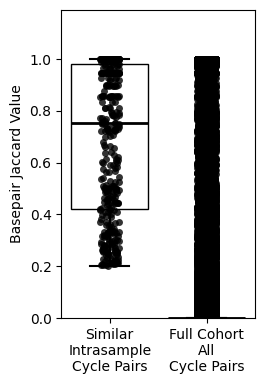

In [16]:
plt.figure(figsize=(2.5, 4))

sns.boxplot(
    x='Pair', y='BP Jaccard', data=filt_v_nofilt_df, palette="Set3", whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0)
)

sns.stripplot(x='Pair', y='BP Jaccard', data=filt_v_nofilt_df, color='black', alpha=0.8, jitter=True)

plt.xlabel("")
plt.xticks(ticks=[0, 1], labels=["Similar\nIntrasample\nCycle Pairs", "Full Cohort\nAll\nCycle Pairs"], fontsize=10)
plt.ylabel("Basepair Jaccard Value")
plt.ylim(0, 1.19)
plt.title("")

plt.show()

In [17]:
group1 = filt_v_nofilt_df[filt_v_nofilt_df["Pair"] == "filtered"]['BP Jaccard']
group2 = filt_v_nofilt_df[filt_v_nofilt_df["Pair"] == "unfiltered"]['BP Jaccard']
stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
n1 = len(group1)
n2 = len(group2)

# calculate Rank-Biserial correlation for effect size
rank_biserial = (2 * (stat - n1 * n2 / 2)) / (n1 * n2)

print("p = " + str(p_value))
print("RB = " + str(rank_biserial))

p = 0.0
RB = 0.9909368657584038


### Supp. Fig. 5C

Text(0.5, 1.0, 'Similar Intrasample Cycle Pairs')

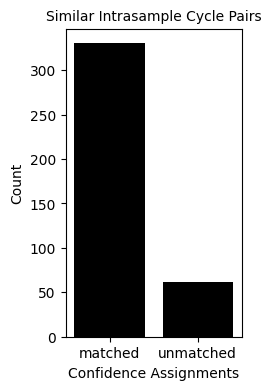

In [18]:
conf_pair_order = ["matched", "unmatched"]

plt.figure(figsize=(5, 4))
plt.subplot(1, 2, 2)
sns.barplot(x=intrasample_pair_confidences_df["Confidence Pair Assignment"].value_counts().index, y=intrasample_pair_confidences_df["Confidence Pair Assignment"].value_counts().values, order=conf_pair_order, color="black")
plt.xlabel("Confidence Assignments")
plt.ylabel("Count")
plt.title("Similar Intrasample Cycle Pairs", fontsize=10)

### Supp. Fig. 5D

Text(0.5, 1.0, 'Similar Intrasample Cycle Pairs')

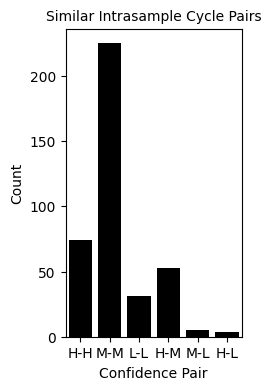

In [19]:
conf_pair_order = ["H-H", "M-M", "L-L", "H-M", "M-L", "H-L"]

plt.figure(figsize=(5, 4))
plt.subplot(1, 2, 2)
sns.barplot(x=intrasample_pair_confidences_df["Confidence Pair"].value_counts().index, y=intrasample_pair_confidences_df["Confidence Pair"].value_counts().values, order=conf_pair_order, color="black")
plt.xlabel("Confidence Pair")
plt.ylabel("Count")
plt.title("Similar Intrasample Cycle Pairs", fontsize=10)